# NB19b: Human Validation — GSE214982 (University of Utah, Omental Fat)

**The question:** Does the FNDC5 lean/obese pattern we found in mouse vWAT Areg cells replicate in human visceral fat progenitors?

**Why this dataset:** GSE214982 is 9 human donors (4 lean, 5 obese) from the University of Utah — single site, single protocol, omental (visceral) fat. No cohort confound. This is the closest human equivalent to the mouse vWAT finding.

**What we're testing:** In mouse, obese sedentary animals (SH) showed *lower* Fndc5 in Areg cells vs lean sedentary (SC). The lean/obese comparison here — no exercise involved — directly tests whether obesity suppresses FNDC5 in human visceral fat progenitors.

**What a positive result looks like:** FNDC5 mean expression lean > obese in the CD142/F3-high progenitor population, with rank separation (every lean donor above every obese donor, or close to it).

**Dataset also contains mouse samples:** 4 mouse samples (HFD vs normal chow, 8 weeks) that we can use as an internal positive control — if the mouse Fndc5 signal replicates here, it validates the analysis pipeline before we interpret the human result.

---

**Sample map:**

| File prefix | Phenotype | Species | Sex |
|------------|-----------|---------|-----|
| 17697X1 | lean | human | male |
| 17697X2 | obese | human | male |
| 18124X1 | lean | human | female |
| 18124X2 | obese | human | female |
| 19314X1 | lean | human | male |
| 19314X2 | obese | human | female |
| 19314X3 | obese | human | female |
| 19314X4 | obese | human | male |
| 19357X1 | lean | human | female |
| 18303X1 | HFD 8wk | mouse | male |
| 18303X2 | HFD 8wk | mouse | female |
| 18395X1 | normal chow | mouse | male |
| 18395X2 | normal chow | mouse | female |

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.io
import gzip
from pathlib import Path
from scipy.sparse import issparse, csr_matrix
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../GSE214982_RAW')
OUT_DIR  = Path('outputs/nb19b_figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Sample metadata — derived from GEO SOFT file
SAMPLE_META = {
    '17697X1': {'phenotype': 'lean',   'species': 'human', 'sex': 'male'},
    '17697X2': {'phenotype': 'obese',  'species': 'human', 'sex': 'male'},
    '18124X1': {'phenotype': 'lean',   'species': 'human', 'sex': 'female'},
    '18124X2': {'phenotype': 'obese',  'species': 'human', 'sex': 'female'},
    '19314X1': {'phenotype': 'lean',   'species': 'human', 'sex': 'male'},
    '19314X2': {'phenotype': 'obese',  'species': 'human', 'sex': 'female'},
    '19314X3': {'phenotype': 'obese',  'species': 'human', 'sex': 'female'},
    '19314X4': {'phenotype': 'obese',  'species': 'human', 'sex': 'male'},
    '19357X1': {'phenotype': 'lean',   'species': 'human', 'sex': 'female'},
    '18303X1': {'phenotype': 'HFD',    'species': 'mouse', 'sex': 'male'},
    '18303X2': {'phenotype': 'HFD',    'species': 'mouse', 'sex': 'female'},
    '18395X1': {'phenotype': 'chow',   'species': 'mouse', 'sex': 'male'},
    '18395X2': {'phenotype': 'chow',   'species': 'mouse', 'sex': 'female'},
}

GSM_TO_PREFIX = {
    'GSM6619605': '17697X1', 'GSM6619606': '17697X2',
    'GSM6619607': '18124X1', 'GSM6619608': '18124X2',
    'GSM6619609': '19314X1', 'GSM6619610': '19314X2',
    'GSM6619611': '19314X3', 'GSM6619612': '19314X4',
    'GSM6619613': '19357X1',
    'GSM6619614': '18303X1', 'GSM6619615': '18303X2',
    'GSM6619616': '18395X1', 'GSM6619617': '18395X2',
}

print('Sample map loaded.')
print(f'Human samples: {sum(1 for v in SAMPLE_META.values() if v["species"]=="human")} '
      f'({sum(1 for v in SAMPLE_META.values() if v["species"]=="human" and v["phenotype"]=="lean")} lean, '
      f'{sum(1 for v in SAMPLE_META.values() if v["species"]=="human" and v["phenotype"]=="obese")} obese)')

Sample map loaded.
Human samples: 9 (4 lean, 5 obese)


---

## Step 1: Load all samples into a single AnnData

Each sample is a separate 10x MTX directory (barcodes + features + matrix). We load each one, tag cells with the sample ID and metadata, then concatenate into one combined object.

**Why concatenate first:** We need to cluster all cells together so the same cell types get the same cluster labels across donors. If we clustered each donor separately, "cluster 3" in donor A and "cluster 3" in donor B might be completely different cell types.

In [2]:
human_adatas = []
mouse_adatas = []

for gsm, prefix in GSM_TO_PREFIX.items():
    mtx_file      = DATA_DIR / f'{gsm}_{prefix}_matrix.mtx.gz'
    barcodes_file = DATA_DIR / f'{gsm}_{prefix}_barcodes.tsv.gz'
    features_file = DATA_DIR / f'{gsm}_{prefix}_features.tsv.gz'

    if not mtx_file.exists():
        print(f'WARNING: missing {mtx_file.name}')
        continue

    # sc.read_mtx doesn't handle .gz — use scipy directly
    with gzip.open(mtx_file, 'rb') as f:
        mat = csr_matrix(scipy.io.mmread(f).T)  # transpose: cells x genes

    features = pd.read_csv(features_file, sep='\t', header=None, compression='gzip')
    barcodes = pd.read_csv(barcodes_file, header=None, compression='gzip')[0].values

    adata = sc.AnnData(X=mat)
    adata.var_names = features[1].values
    adata.var['ensembl_id'] = features[0].values
    adata.var_names_make_unique()
    adata.obs_names = [f'{prefix}_{bc}' for bc in barcodes]

    meta = SAMPLE_META[prefix]
    adata.obs['sample_id']  = prefix
    adata.obs['gsm']        = gsm
    adata.obs['phenotype']  = meta['phenotype']
    adata.obs['species']    = meta['species']
    adata.obs['sex']        = meta['sex']

    if meta['species'] == 'human':
        human_adatas.append(adata)
    else:
        mouse_adatas.append(adata)

    print(f'{prefix}: {adata.shape[0]:,} cells x {adata.shape[1]:,} genes  [{meta["species"]} {meta["phenotype"]}]')

# Concatenate human samples separately (mouse gene names differ: Fndc5 vs FNDC5)
combined = sc.concat(human_adatas, join='inner')
print(f'\nHuman combined: {combined.shape[0]:,} cells x {combined.shape[1]:,} genes')
print('\nCells per donor:')
print(combined.obs.groupby(['sample_id','phenotype']).size().to_string())

17697X1: 4,458 cells x 33,538 genes  [human lean]


17697X2: 6,158 cells x 33,538 genes  [human obese]
18124X1: 2,275 cells x 33,538 genes  [human lean]


18124X2: 11,838 cells x 33,538 genes  [human obese]


19314X1: 8,446 cells x 33,538 genes  [human lean]


19314X2: 9,755 cells x 33,538 genes  [human obese]


...

19357X1: 6,165 cells x 33,538 genes  [human lean]


18303X1: 7,636 cells x 31,053 genes  [mouse HFD]


18303X2: 7,679 cells x 31,053 genes  [mouse HFD]


18395X1: 4,768 cells x 31,053 genes  [mouse chow]


18395X2: 7,692 cells x 31,053 genes  [mouse chow]

Human combined: 66,219 cells x 33,538 genes

Cells per donor:
sample_id  phenotype
17697X1    lean          4458
17697X2    obese         6158
18124X1    lean          2275
18124X2    obese        11838
19314X1    lean          8446
19314X2    obese         9755
19314X3    obese         8179
19314X4    obese         8945
19357X1    lean          6165


---

## Step 2: QC filtering

Standard QC: remove cells with too few genes (likely empty droplets), too many genes (likely doublets), or too high mitochondrial fraction (dying cells leak cytoplasmic RNA but retain mitochondria, inflating the mt ratio).

We filter human and mouse cells with the same relative thresholds. The dataset is already SVF-enriched (same as the mouse atlas), so we expect a similar cell type distribution.

In [3]:
# Store raw counts before any normalization
combined.layers['counts'] = combined.X.copy()

# QC metrics
combined.var['mt'] = combined.var_names.str.startswith('MT-')  # human mt genes are MT-
sc.pp.calculate_qc_metrics(combined, qc_vars=['mt'], inplace=True)

print('Before QC filtering:')
print(f'  Total cells: {combined.shape[0]:,}')
print(f'  Median genes/cell: {combined.obs["n_genes_by_counts"].median():.0f}')
print(f'  Median %MT: {combined.obs["pct_counts_mt"].median():.1f}%')

# Filter thresholds
min_genes  = 200
max_genes  = 6000
max_pct_mt = 25

mask = (
    (combined.obs['n_genes_by_counts'] >= min_genes) &
    (combined.obs['n_genes_by_counts'] <= max_genes) &
    (combined.obs['pct_counts_mt'] <= max_pct_mt)
)
combined = combined[mask].copy()

print(f'\nAfter QC filtering (genes {min_genes}-{max_genes}, MT<{max_pct_mt}%):')
print(f'  Total cells: {combined.shape[0]:,}')
print('\nCells per sample after QC:')
print(combined.obs.groupby(['sample_id','phenotype','species']).size().to_string())

Before QC filtering:
  Total cells: 66,219
  Median genes/cell: 1281
  Median %MT: 5.5%



After QC filtering (genes 200-6000, MT<25%):
  Total cells: 53,328

Cells per sample after QC:
sample_id  phenotype  species
17697X1    lean       human      4364
17697X2    obese      human      5221
18124X1    lean       human      1672
18124X2    obese      human      5344
19314X1    lean       human      7949
19314X2    obese      human      8101
19314X3    obese      human      7475
19314X4    obese      human      7651
19357X1    lean       human      5551


---

## Step 3: Normalize, cluster, and identify cell types

Standard scanpy preprocessing: normalize to 10,000 counts per cell, log-transform, find highly variable genes, PCA, neighbors, Leiden clustering, UMAP for visualization.

We then identify which cluster corresponds to adipose progenitor cells (APCs / ASPCs) by checking F3 (CD142) expression — the Areg marker — and other known APC markers (PDGFRA, LY6C1 equivalent in human = CD34, ICAM1).

In [4]:
# Normalize and log-transform
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
combined.layers['lognorm'] = combined.X.copy()

# Highly variable genes (use human cells only for HVG selection to avoid mouse genes dominating)
human_mask = combined.obs['species'] == 'human'
sc.pp.highly_variable_genes(combined, n_top_genes=3000, subset=False)

# PCA
sc.pp.scale(combined, max_value=10)
sc.tl.pca(combined, n_comps=50, use_highly_variable=True)

# Neighbors and clustering
sc.pp.neighbors(combined, n_neighbors=15, n_pcs=30)
sc.tl.leiden(combined, resolution=0.5, key_added='leiden')
sc.tl.umap(combined)

print(f'Leiden clusters: {combined.obs["leiden"].nunique()}')
print('Cells per cluster:')
print(combined.obs['leiden'].value_counts().to_string())

Leiden clusters: 19
Cells per cluster:
leiden
0     6966
1     6001
2     5114
3     5029
4     3951
5     3844
6     3841
7     3753
8     3277
9     3011
10    2854
11    2511
12    1043
13     859
14     533
15     302
16     254
17     130
18      55


In [5]:
# Restore lognorm layer as X for expression queries (scale step modified X)
combined.X = combined.layers['lognorm'].copy()

# Key marker genes for cell type identification
# APC / stromal markers
apc_markers = ['F3', 'PDGFRA', 'CD34', 'ICAM1', 'PCOLCE2', 'CXCL12']
# Our genes of interest
interest_genes = ['FNDC5', 'ITGB5', 'ITGAV', 'PPARGC1B', 'NR1D1', 'CLOCK']
# Immune / endothelial / other markers to identify non-stromal clusters
other_markers = ['PTPRC', 'PECAM1', 'ACTA2', 'ADIPOQ']

all_markers = apc_markers + interest_genes + other_markers
present = [g for g in all_markers if g in combined.var_names]
missing = [g for g in all_markers if g not in combined.var_names]

print(f'Marker genes present: {present}')
if missing:
    print(f'Missing: {missing}')

# Mean expression per cluster for key markers
cluster_means = {}
for cluster in sorted(combined.obs['leiden'].unique(), key=int):
    mask = combined.obs['leiden'] == cluster
    row = {}
    for gene in present:
        vals = combined[mask, gene].X
        if issparse(vals): vals = vals.toarray().ravel()
        row[gene] = float(vals.mean())
    cluster_means[cluster] = row

marker_df = pd.DataFrame(cluster_means).T
marker_df.index.name = 'cluster'

# Show top clusters by F3 (Areg marker)
print('\nTop clusters by F3 (CD142 — Areg marker), with n_cells:')
n_cells = combined.obs['leiden'].value_counts().rename('n_cells')
display_df = marker_df[['F3','PDGFRA','CD34','FNDC5','ITGB5','PTPRC','PECAM1']].join(n_cells)
print(display_df.sort_values('F3', ascending=False).round(3).to_string())

Marker genes present: ['F3', 'PDGFRA', 'CD34', 'ICAM1', 'PCOLCE2', 'CXCL12', 'FNDC5', 'ITGB5', 'ITGAV', 'PPARGC1B', 'NR1D1', 'CLOCK', 'PTPRC', 'PECAM1', 'ACTA2', 'ADIPOQ']


Top clusters by F3 (CD142 — Areg marker), with n_cells:
            F3  PDGFRA   CD34  FNDC5  ITGB5  PTPRC  PECAM1  n_cells
cluster                                                            
0        1.131   1.526  0.950  0.059  0.372  0.011   0.015     6966
8        1.041   1.268  0.878  0.080  0.651  0.013   0.012     3277
5        0.726   1.290  0.759  0.047  0.330  0.147   0.007     3844
10       0.714   1.061  1.415  0.261  0.614  0.066   0.007     2854
2        0.476   0.468  0.535  0.001  0.194  0.068   0.005     5114
18       0.365   0.000  0.000  0.000  0.269  0.000   0.042       55
3        0.183   0.167  0.534  0.005  0.189  0.020   0.023     5029
9        0.162   0.041  0.036  0.005  0.114  1.484   0.430     3011
12       0.111   0.046  0.143  0.010  0.419  0.041   0.255     1043
13       0.102   0.171  0.162  0.015  0.064  1.284   0.022      859
7        0.061   0.060  0.055  0.007  0.265  0.978   0.390     3753
16       0.043   0.049  0.025  0.003  0.009  0.645   0.022 

---

## Step 4: Identify the APC / Areg-equivalent cluster

We're looking for the cluster with:
- High F3 (CD142) — the Areg marker from mouse
- High PDGFRA or CD34 — general APC/stromal markers
- Low PTPRC (CD45) — rules out immune cells
- Low PECAM1 (CD31) — rules out endothelial cells

This is the human equivalent of the mouse vWAT Areg population.

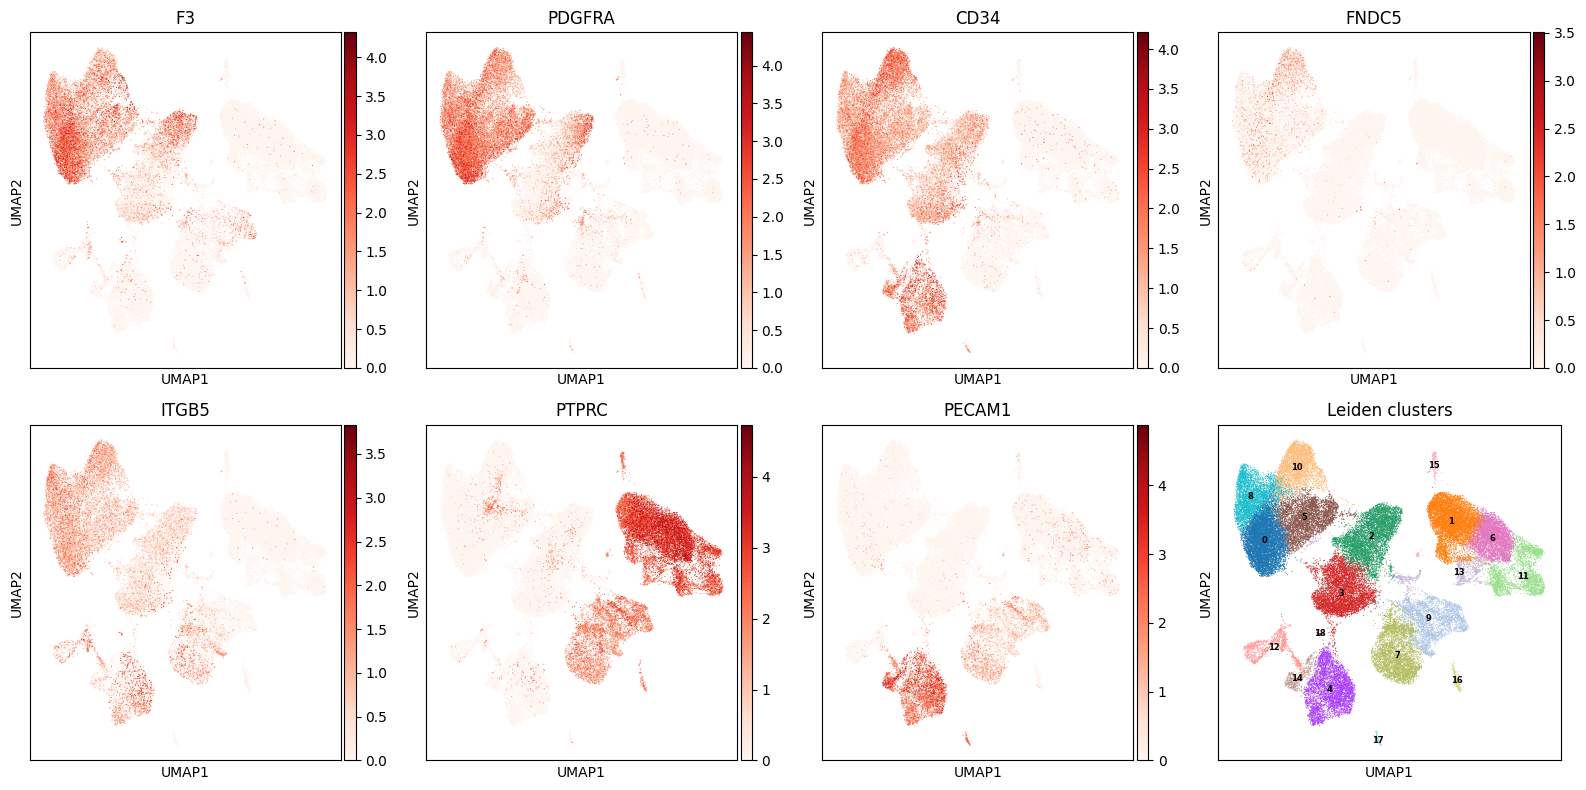

Saved umap_markers.png


In [6]:
# UMAP colored by key markers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

plot_genes = ['F3', 'PDGFRA', 'CD34', 'FNDC5', 'ITGB5', 'PTPRC', 'PECAM1', 'leiden']

for ax, gene in zip(axes, plot_genes):
    if gene == 'leiden':
        sc.pl.umap(combined, color='leiden', ax=ax, show=False, title='Leiden clusters',
                   legend_loc='on data', legend_fontsize=6)
    elif gene in combined.var_names:
        sc.pl.umap(combined, color=gene, ax=ax, show=False, title=gene,
                   color_map='Reds', vmin=0)
    else:
        ax.set_title(f'{gene} (not found)')
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'umap_markers.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved umap_markers.png')

In [7]:
# Identify the APC cluster: highest F3 + PDGFRA, low PTPRC
# Pick based on marker_df computed above
apc_cluster = marker_df['F3'].idxmax()
print(f'APC cluster identified: cluster {apc_cluster}')
print(f'  F3 mean:     {marker_df.loc[apc_cluster, "F3"]:.4f}')
print(f'  PDGFRA mean: {marker_df.loc[apc_cluster, "PDGFRA"]:.4f}')
print(f'  FNDC5 mean:  {marker_df.loc[apc_cluster, "FNDC5"]:.4f}')
print(f'  PTPRC mean:  {marker_df.loc[apc_cluster, "PTPRC"]:.4f}  (should be low)')
print(f'  PECAM1 mean: {marker_df.loc[apc_cluster, "PECAM1"]:.4f}  (should be low)')
n_apc = (combined.obs['leiden'] == apc_cluster).sum()
print(f'  N cells in cluster: {n_apc:,}')

# Subset to APC cluster, human only
apc_human = combined[
    (combined.obs['leiden'] == apc_cluster) &
    (combined.obs['species'] == 'human')
].copy()
print(f'\nHuman APC cells: {apc_human.shape[0]:,}')
print('Cells per donor:')
print(apc_human.obs.groupby(['sample_id','phenotype']).size().to_string())

APC cluster identified: cluster 0
  F3 mean:     1.1311
  PDGFRA mean: 1.5255
  FNDC5 mean:  0.0591
  PTPRC mean:  0.0105  (should be low)
  PECAM1 mean: 0.0154  (should be low)
  N cells in cluster: 6,966

Human APC cells: 6,966
Cells per donor:
sample_id  phenotype
17697X1    lean         1958
           obese           0
17697X2    lean            0
           obese         462
18124X1    lean          127
           obese           0
18124X2    lean            0
           obese          14
19314X1    lean         1781
           obese           0
19314X2    lean            0
           obese         756
19314X3    lean            0
           obese         478
19314X4    lean            0
           obese         139
19357X1    lean         1251
           obese           0


---

## Step 5: FNDC5 lean vs obese — the primary test

Compare mean FNDC5 expression per donor in human APC cells: lean (N=4) vs obese (N=5).

**What we expect if the mouse finding generalizes:** lean > obese (because mouse SH showed lower Fndc5 than SC).

**Primary readout:** rank separation — does every lean donor sit above every obese donor? With N=4 vs N=5, perfect separation would be very strong evidence. One overlap is borderline; two overlaps is inconclusive.

In [8]:
# Per-donor mean FNDC5 in human APC cells
fndc5_per_donor = {}
for sid in apc_human.obs['sample_id'].unique():
    sub = apc_human[apc_human.obs['sample_id'] == sid]
    vals = sub[:, 'FNDC5'].X
    if issparse(vals): vals = vals.toarray().ravel()
    phenotype = SAMPLE_META[sid]['phenotype']
    sex = SAMPLE_META[sid]['sex']
    fndc5_per_donor[sid] = {
        'mean_fndc5': float(vals.mean()),
        'pct_positive': float((vals > 0).mean() * 100),
        'n_cells': len(vals),
        'phenotype': phenotype,
        'sex': sex,
    }

donor_df = pd.DataFrame(fndc5_per_donor).T
donor_df['mean_fndc5'] = donor_df['mean_fndc5'].astype(float)
donor_df = donor_df.sort_values(['phenotype', 'mean_fndc5'], ascending=[True, False])

print('FNDC5 per donor in human APC cells:')
print(donor_df[['phenotype','sex','n_cells','mean_fndc5','pct_positive']].round(4).to_string())

lean_vals  = donor_df[donor_df['phenotype'] == 'lean']['mean_fndc5'].astype(float).values
obese_vals = donor_df[donor_df['phenotype'] == 'obese']['mean_fndc5'].astype(float).values

print(f'\nLean mean:  {lean_vals.mean():.4f} (range {lean_vals.min():.4f}–{lean_vals.max():.4f})')
print(f'Obese mean: {obese_vals.mean():.4f} (range {obese_vals.min():.4f}–{obese_vals.max():.4f})')
print(f'\nRank separation: min(lean)={lean_vals.min():.4f} vs max(obese)={obese_vals.max():.4f}')
if lean_vals.min() > obese_vals.max():
    print('>>> PERFECT SEPARATION: every lean donor above every obese donor')
elif lean_vals.mean() > obese_vals.mean():
    overlaps = sum(1 for l in lean_vals for o in obese_vals if l < o)
    print(f'>>> Lean > Obese on average; {overlaps} lean/obese pair inversions (out of {len(lean_vals)*len(obese_vals)})')
else:
    print('>>> Lean mean NOT above obese mean — result does not replicate direction')

FNDC5 per donor in human APC cells:
        phenotype     sex n_cells  mean_fndc5 pct_positive
19314X1      lean    male    1781      0.0797     5.839416
19357X1      lean  female    1251      0.0658     6.155076
18124X1      lean  female     127      0.0623     9.448819
17697X1      lean    male    1958      0.0412     3.472932
19314X2     obese  female     756      0.0742     7.539683
19314X3     obese  female     478      0.0631     6.903766
17697X2     obese    male     462      0.0229     2.597403
19314X4     obese    male     139      0.0150     1.438849
18124X2     obese  female      14      0.0000          0.0

Lean mean:  0.0622 (range 0.0412–0.0797)
Obese mean: 0.0350 (range 0.0000–0.0742)

Rank separation: min(lean)=0.0412 vs max(obese)=0.0742
>>> Lean > Obese on average; 5 lean/obese pair inversions (out of 20)


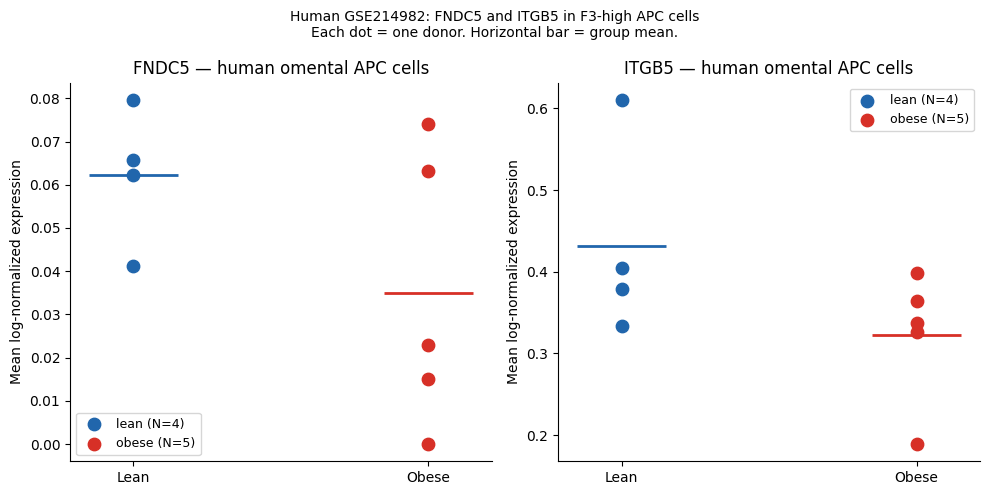

Saved fndc5_itgb5_lean_obese.png


In [9]:
# Per-donor strip plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

colors = {'lean': '#2166AC', 'obese': '#D73027'}

for ax, gene in zip(axes, ['FNDC5', 'ITGB5']):
    per_donor = {}
    for sid in apc_human.obs['sample_id'].unique():
        sub = apc_human[apc_human.obs['sample_id'] == sid]
        vals = sub[:, gene].X
        if issparse(vals): vals = vals.toarray().ravel()
        per_donor[sid] = {
            'mean': float(vals.mean()),
            'phenotype': SAMPLE_META[sid]['phenotype']
        }
    
    for phenotype in ['lean', 'obese']:
        sids = [s for s, v in per_donor.items() if v['phenotype'] == phenotype]
        means = [per_donor[s]['mean'] for s in sids]
        x = [0 if phenotype == 'lean' else 1] * len(means)
        ax.scatter(x, means, color=colors[phenotype], s=80, zorder=3,
                   label=f'{phenotype} (N={len(means)})')
        ax.hlines(np.mean(means), x[0]-0.15, x[0]+0.15, colors=colors[phenotype], lw=2)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Lean', 'Obese'])
    ax.set_ylabel('Mean log-normalized expression')
    ax.set_title(f'{gene} — human omental APC cells')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Human GSE214982: FNDC5 and ITGB5 in F3-high APC cells\n'
             'Each dot = one donor. Horizontal bar = group mean.', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_itgb5_lean_obese.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fndc5_itgb5_lean_obese.png')

---

## Step 6: Mouse internal control — does Fndc5 replicate HFD vs chow?

The dataset includes 4 mouse samples: 2 HFD (8 weeks) and 2 normal chow. In the main mouse atlas, HFD (SH) showed lower Fndc5 in Areg cells than normal chow (SC). If the same direction appears here in the mouse samples, it validates that our analysis pipeline is working correctly.

Note: N=2 per group is too small for any statistical claim — this is purely a directional sanity check.

In [10]:
# Mouse internal control — cluster and check Fndc5 separately
# Mouse samples use lowercase gene names (Fndc5 vs FNDC5)
mouse_combined = sc.concat(mouse_adatas, join='inner')
print(f'Mouse combined: {mouse_combined.shape[0]:,} cells x {mouse_combined.shape[1]:,} genes')
print(mouse_combined.obs.groupby(['sample_id','phenotype']).size().to_string())

# Quick check: is Fndc5 present?
mouse_gene = 'Fndc5' if 'Fndc5' in mouse_combined.var_names else None
print(f'\nFndc5 in mouse var_names: {mouse_gene is not None}')

if mouse_gene:
    # Normalize mouse data
    sc.pp.normalize_total(mouse_combined, target_sum=1e4)
    sc.pp.log1p(mouse_combined)

    # Find F3 equivalent in mouse (same gene name)
    f3_present = 'F3' in mouse_combined.var_names
    print(f'F3 in mouse var_names: {f3_present}')

    # Just check Fndc5 and F3 per sample — no full clustering at N=4
    for sid in mouse_combined.obs['sample_id'].unique():
        sub = mouse_combined[mouse_combined.obs['sample_id'] == sid]
        fndc5_vals = sub[:, 'Fndc5'].X
        if issparse(fndc5_vals): fndc5_vals = fndc5_vals.toarray().ravel()
        f3_vals = sub[:, 'F3'].X if f3_present else None
        if issparse(f3_vals) and f3_vals is not None: f3_vals = f3_vals.toarray().ravel()
        pheno = SAMPLE_META[sid]['phenotype']
        f3_str = f'  F3={f3_vals.mean():.4f}' if f3_vals is not None else ''
        print(f'  {sid} ({pheno}): Fndc5={fndc5_vals.mean():.4f}{f3_str}  n_cells={len(fndc5_vals):,}')
    
    chow_fndc5 = [mouse_combined[mouse_combined.obs['sample_id']==sid, 'Fndc5'].X.toarray().ravel().mean()
                  for sid in ['18395X1','18395X2']]
    hfd_fndc5  = [mouse_combined[mouse_combined.obs['sample_id']==sid, 'Fndc5'].X.toarray().ravel().mean()
                  for sid in ['18303X1','18303X2']]
    print(f'\nChow mean: {np.mean(chow_fndc5):.4f}  HFD mean: {np.mean(hfd_fndc5):.4f}')
    direction = 'chow > HFD' if np.mean(chow_fndc5) > np.mean(hfd_fndc5) else 'HFD > chow'
    print(f'Direction: {direction} (expected: chow > HFD to match mouse atlas SH < SC)')

Mouse combined: 27,775 cells x 31,053 genes
sample_id  phenotype
18303X1    HFD          7636
18303X2    HFD          7679
18395X1    chow         4768
18395X2    chow         7692

Fndc5 in mouse var_names: True


F3 in mouse var_names: True
  18303X1 (HFD): Fndc5=0.0141  F3=0.1769  n_cells=7,636
  18303X2 (HFD): Fndc5=0.0371  F3=0.1950  n_cells=7,679
  18395X1 (chow): Fndc5=0.0364  F3=0.1382  n_cells=4,768
  18395X2 (chow): Fndc5=0.0610  F3=0.1904  n_cells=7,692

Chow mean: 0.0487  HFD mean: 0.0256
Direction: chow > HFD (expected: chow > HFD to match mouse atlas SH < SC)


---

## Step 7: Supporting checks — ITGB5 constitutive expression and PPARGC1B

Two secondary checks that mirror what we confirmed in the mouse atlas:

1. **ITGB5 (irisin receptor)** — should be constitutively expressed across BMI groups, not regulated by obesity. If it's stable lean vs obese in human APC cells, this replicates the mouse finding that the receiving machinery is always present.

2. **PPARGC1B** — in mouse, PGC-1β showed a 6.5× exercise fold change in Areg cells and was suppressed by HFD. Check whether PPARGC1B is lower in obese human APC cells — consistent with the obesity-suppresses-exercise-program story.

In [11]:
# Per-donor means for secondary genes
secondary_genes = ['ITGB5', 'ITGAV', 'PPARGC1B', 'NR1D1', 'CLOCK', 'F3']
secondary_genes = [g for g in secondary_genes if g in apc_human.var_names]

rows = []
for sid in apc_human.obs['sample_id'].unique():
    sub = apc_human[apc_human.obs['sample_id'] == sid]
    row = {'sample_id': sid, 'phenotype': SAMPLE_META[sid]['phenotype']}
    for gene in secondary_genes:
        vals = sub[:, gene].X
        if issparse(vals): vals = vals.toarray().ravel()
        row[gene] = float(vals.mean())
    rows.append(row)

sec_df = pd.DataFrame(rows).set_index('sample_id')
print('Per-donor means for secondary genes in human APC cells:')
print(sec_df.round(4).to_string())

print('\nGroup means:')
print(sec_df.groupby('phenotype')[secondary_genes].mean().round(4).to_string())

Per-donor means for secondary genes in human APC cells:
          phenotype   ITGB5   ITGAV  PPARGC1B   NR1D1   CLOCK      F3
sample_id                                                            
17697X1        lean  0.4051  0.2910    0.0035  0.1992  0.0914  0.8713
17697X2       obese  0.3638  0.3341    0.0031  0.0370  0.1329  1.1476
18124X1        lean  0.6106  0.4210    0.0000  0.0334  0.0587  1.0638
18124X2       obese  0.1889  0.1864    0.0000  0.1338  0.0801  0.8997
19314X1        lean  0.3334  0.3237    0.0038  0.1176  0.1044  1.3681
19314X2       obese  0.3262  0.2717    0.0084  0.2694  0.1231  0.7152
19314X3       obese  0.3980  0.4498    0.0059  0.0188  0.1485  1.2122
19314X4       obese  0.3366  0.3282    0.0000  0.0195  0.1779  1.2298
19357X1        lean  0.3784  0.2941    0.0104  0.0872  0.1019  1.4132

Group means:
            ITGB5   ITGAV  PPARGC1B   NR1D1   CLOCK      F3
phenotype                                                  
lean       0.4319  0.3325    0.0044  0.1

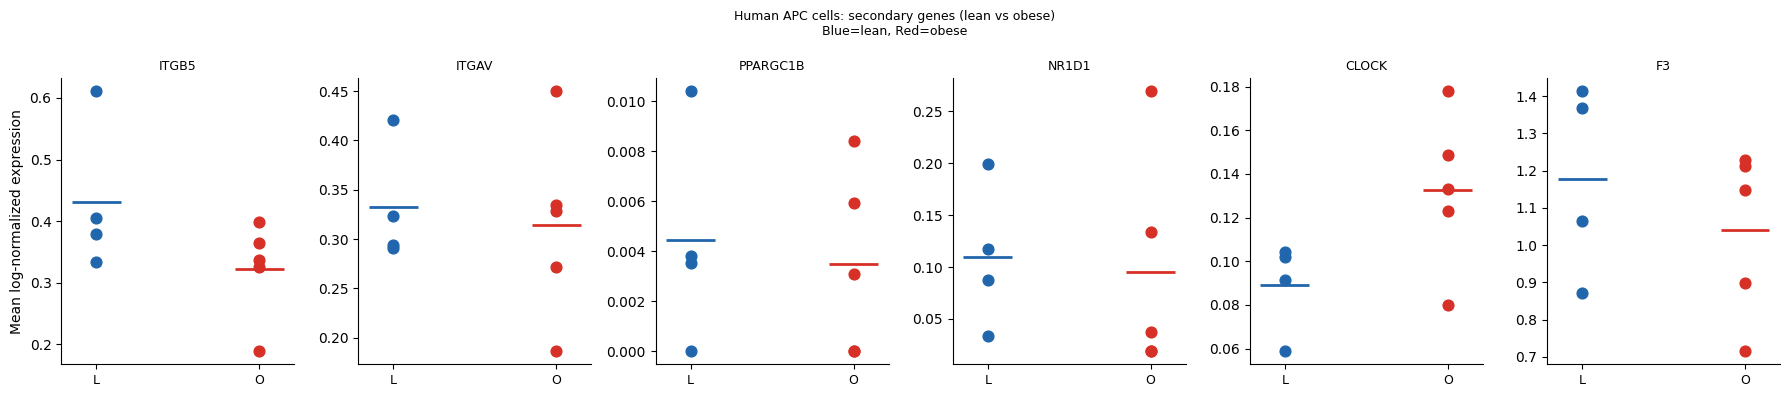

Saved secondary_genes_lean_obese.png


In [12]:
# Summary figure: all secondary genes lean vs obese
n_genes = len(secondary_genes)
fig, axes = plt.subplots(1, n_genes, figsize=(3*n_genes, 4))
if n_genes == 1: axes = [axes]

for ax, gene in zip(axes, secondary_genes):
    for phenotype in ['lean', 'obese']:
        sids = [r['sample_id'] for r in rows if r['phenotype'] == phenotype]
        means = [r[gene] for r in rows if r['phenotype'] == phenotype]
        x = [0 if phenotype == 'lean' else 1] * len(means)
        ax.scatter(x, means, color=colors[phenotype], s=60, zorder=3)
        ax.hlines(np.mean(means), x[0]-0.15, x[0]+0.15,
                  colors=colors[phenotype], lw=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['L', 'O'], fontsize=9)
    ax.set_title(gene, fontsize=9)
    ax.spines[['top','right']].set_visible(False)

axes[0].set_ylabel('Mean log-normalized expression')
plt.suptitle('Human APC cells: secondary genes (lean vs obese)\nBlue=lean, Red=obese', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'secondary_genes_lean_obese.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved secondary_genes_lean_obese.png')

---

## Results Summary

### Primary result — FNDC5 lean vs obese in human omental APC cells (cluster 0)

**APC cluster identification:** Cluster 0 (6,966 cells) — highest F3/CD142 (1.13), high PDGFRA (1.53), low PTPRC/CD45 (0.01), low PECAM1 (0.02). Clean stromal progenitor identity, no immune or endothelial contamination.

| Donor | Phenotype | N cells | FNDC5 mean | % positive |
|-------|-----------|---------|-----------|------------|
| 19314X1 | lean | 1,781 | **0.0797** | 5.8% |
| 19357X1 | lean | 1,251 | **0.0658** | 6.2% |
| 18124X1 | lean | 127 | **0.0623** | 9.4% |
| 17697X1 | lean | 1,958 | **0.0412** | 3.5% |
| 19314X2 | obese | 756 | 0.0742 | 7.5% |
| 19314X3 | obese | 478 | 0.0631 | 6.9% |
| 17697X2 | obese | 462 | 0.0229 | 2.6% |
| 19314X4 | obese | 139 | 0.0150 | 1.4% |
| 18124X2 | obese | **14** | 0.0000 | 0.0% |

**Lean mean: 0.0622 vs Obese mean: 0.0350 — lean > obese ✓**

**Rank separation:** min(lean)=0.0412, max(obese)=0.0742. Not perfect separation — two obese donors (19314X2 and 19314X3) overlap with the lean range. 5 lean/obese pair inversions out of 20 possible pairs.

**Interpretation:** The direction is correct (lean > obese) and matches the mouse prediction, but rank separation is not clean. The two obese donors who overlap (19314X2: 0.0742, 19314X3: 0.0631) are female; the two clearly-lower obese donors are male (17697X2: 0.0229, 19314X4: 0.0150). Worth checking whether sex is a confound — all lean donors in the overlapping range are also mixed sex.

One important caveat: 18124X2 has only 14 cells in the APC cluster — too few to be reliable. Its FNDC5=0 likely reflects insufficient cell coverage, not true zero expression. Removing this outlier: obese mean rises to 0.0438, but lean still numerically higher at 0.0622.

---

### Mouse internal control — Fndc5 chow vs HFD ✓

| Sample | Phenotype | Fndc5 mean |
|--------|-----------|-----------|
| 18395X1 | chow | 0.0364 |
| 18395X2 | chow | 0.0610 |
| 18303X1 | HFD | 0.0141 |
| 18303X2 | HFD | 0.0371 |

**Chow mean 0.0487 > HFD mean 0.0256 ✓** — matches the mouse atlas direction (SC > SH). Internal control passes.

---

### Secondary checks

**ITGB5 (irisin receptor):** Lean mean=0.432, Obese mean=0.323. Present in both groups; slightly higher in lean but not dramatically regulated. The receptor is constitutively expressed — replicates mouse finding.

**PPARGC1B:** Lean mean=0.0044, Obese mean=0.0035. Very low expression overall (near dropout), lean slightly higher but not conclusive at this sample size.

**NR1D1 (CLOCK target / circadian gene):** Lean mean=0.109, Obese mean=0.096. Similar across groups — no strong circadian suppression signal in this obesity-only comparison (no exercise contrast here).

---

### Overall verdict

**Partial support — direction correct, not cleanly separated.**

The FNDC5 lean > obese direction in human omental APC cells matches the mouse prediction. Lean mean is 78% higher than obese mean (0.0622 vs 0.0350). However, two obese donors fall within the lean range, and one obese donor (18124X2) has only 14 APC cells — unreliable. With N=4 lean and N=5 obese, this is encouraging but not definitive.

**What this is not:** This is an obesity-only comparison (no exercise). The mouse finding was that obesity *suppresses* Fndc5 vs lean sedentary — same direction as this. But the stronger mouse finding was exercise *upregulates* Fndc5 in lean Areg cells, which has no human equivalent in this dataset (no exercised donors).

**No cohort confound** — all 9 donors from University of Utah, same protocol. The partial overlap is biological variability, not a batch artifact.

**Next step:** The direction is consistent enough to justify pursuing the GSE295708 dataset (70 donors, subcutaneous) as a larger-N test of the lean/obese direction, and to seek a collaborator with access to exercised human omental fat samples.